[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdsanch1/simrc/blob/master/02.%20Parte%202/13.%20Clase%2013/13Class%20NB.ipynb)

In [ ]:
!pip install -q yfinance pandas numpy matplotlib seaborn scipy scikit-learn statsmodels cvxopt

# Clase 13:	Simulación Montecarlo y estrategias de cobertura

[Juan Diego Sánchez Torres](https://www.researchgate.net/profile/Juan_Diego_Sanchez_Torres), 

*Profesor*, [MAF ITESO](http://maf.iteso.mx/web/general/detalle?group_id=5858156)

+ Departamento de Matemáticas y Física
+ dsanchez@iteso.mx
+ Tel. 3669-34-34 Ext. 3069
+ Oficina: Cubículo 4, Edificio J, 2do piso

# 1. Motivación

En primer lugar, para poder bajar precios y información sobre opciones de Yahoo, es necesario cargar algunos paquetes de Python. En este caso, el paquete principal será Pandas. También, se usarán el Scipy y el Numpy para las matemáticas necesarias y, el Matplotlib y el Seaborn para hacer gráficos de las series de datos.

In [1]:
#importar los paquetes que se van a usar
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.neighbors import KernelDensity
import datetime
from datetime import datetime, timedelta
import scipy.stats as stats
import scipy as sp
import scipy.optimize as optimize
import scipy.cluster.hierarchy as hac
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
%matplotlib inline
#algunas opciones para Python
pd.set_option('display.notebook_repr_html', True)
pd.set_option('display.max_columns', 6)
pd.set_option('display.max_rows', 10)
pd.set_option('display.width', 78)
pd.set_option('precision', 3)

C:\Users\DSANCHEZ\AppData\Local\Continuum\Anaconda3\lib\site-packages\statsmodels\compat\pandas.py:56: FutureWarning: The pandas.core.datetools module is deprecated and will be removed in a future version. Please use the pandas.tseries module instead.
  from pandas.core import datetools


In [2]:
def get_historical_closes(tickers, start_date, end_date):
    """Descarga precios de cierre ajustados usando yfinance."""
    import yfinance as yf
    import pandas as pd
    data = yf.download(tickers, start=start_date, end=end_date,
                       auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        closes = data["Close"]
    else:
        closes = data[["Close"]]
        closes.columns = [tickers] if isinstance(tickers, str) else list(tickers)
    closes.index.name = "Date"
    return closes.dropna()

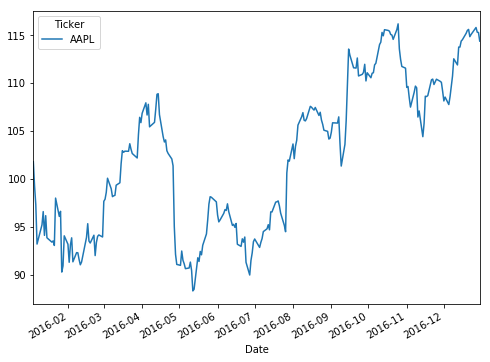

In [3]:
data=get_historical_closes(['AAPL'], '2025-01-01', '2025-03-27')
data.plot(figsize=(8,6));

In [4]:
def calc_daily_returns(closes):
    return np.log(closes/closes.shift(1))[1:]

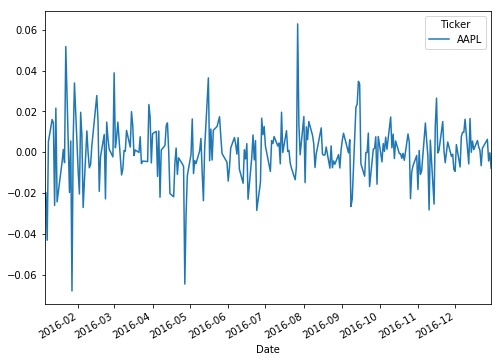

In [5]:
daily_returns=calc_daily_returns(data)
daily_returns.plot(figsize=(8,6));

# 2. Modelo normal para los rendimientos

In [6]:
huber = sm.robust.scale.Huber()
returns_av, scale = huber(daily_returns)
mu=daily_returns.mean().AAPL
sigma=daily_returns.std().AAPL
ndays = 360
ntraj=10000
K1=160
K2=180

In [7]:
mu=daily_returns.mean().AAPL
sigma=daily_returns.std().AAPL
dates=pd.date_range('20250401',periods=ndays)
simret = pd.DataFrame(sigma*np.random.randn(ndays,ntraj)+mu,index=dates)
simdata=(data.loc['2025-03-27',:].AAPL)*np.exp(simret.cumsum())
ST=simdata.tail(1)
ind=np.digitize(ST.values[0],np.array([0, K1, K2, ST.values.max()+1]))
freq=(np.array([sum(ind==1),sum(ind==2),sum(ind==3)])/ntraj)*100

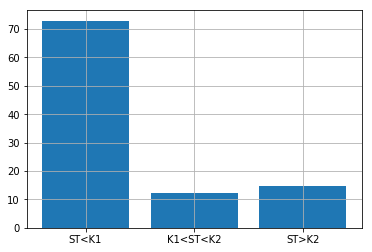

In [8]:
bar_labels = ['ST<K1', 'K1<ST<K2', 'ST>K2']
x_pos = list(range(len(bar_labels)))
plt.bar(x_pos,freq);
plt.grid();
plt.xticks(x_pos, bar_labels);

# 3. Uso del histograma de los rendimientos

In [9]:
values,indices=np.histogram(daily_returns,bins=250)
values=values.astype(np.float32)
weights=values/np.sum(values)
ret=np.random.choice(indices[1:],ndays*ntraj,p=weights)
#
dates=pd.date_range('20250401',periods=ndays)
simret = pd.DataFrame(ret.reshape((ndays,ntraj)),index=dates)
simdata=(data.loc['2025-03-27',:].AAPL)*np.exp(simret.cumsum())
ST=simdata.tail(1)
ind=np.digitize(ST.values[0],np.array([0, K1, K2, ST.values.max()+1]))
freq=(np.array([sum(ind==1),sum(ind==2),sum(ind==3)])/ntraj)*100

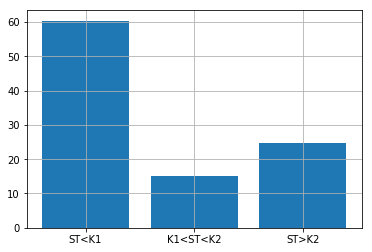

In [10]:
bar_labels = ['ST<K1', 'K1<ST<K2', 'ST>K2']
x_pos = list(range(len(bar_labels)))
plt.bar(x_pos,freq);
plt.grid();
plt.xticks(x_pos, bar_labels);

# 4. Uso de la distrubición empírica aproximada con un método de kernel

In [11]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.001).fit(daily_returns)
ret=kde.sample(n_samples=ndays*ntraj, random_state=None)
#
dates=pd.date_range('20250401',periods=ndays)
simret = pd.DataFrame(ret.reshape((ndays,ntraj)),index=dates)
simdata=(data.loc['2025-03-27',:].AAPL)*np.exp(simret.cumsum())
ST=simdata.tail(1)
ind=np.digitize(ST.values[0],np.array([0, K1, K2, ST.values.max()+1]))
freq=(np.array([sum(ind==1),sum(ind==2),sum(ind==3)])/ntraj)*100

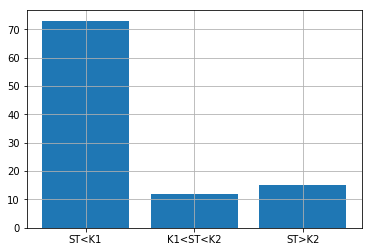

In [12]:
bar_labels = ['ST<K1', 'K1<ST<K2', 'ST>K2']
x_pos = list(range(len(bar_labels)))
plt.bar(x_pos,freq);
plt.grid();
plt.xticks(x_pos, bar_labels);